In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestRegressor
import seaborn as sns
import xgboost as xgb

%matplotlib inline

In [2]:
# Importing dataset
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [3]:
print(df.isnull().sum())
df = df.fillna(0.0)

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64


In [4]:
print(df.isnull().sum())

model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
fuel_efficiency_mpg    0
dtype: int64


In [5]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [6]:
dv = DictVectorizer(sparse=True)

train_dict = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val.to_dict(orient='records')
X_val = dv.transform(val_dict)

In [10]:
"""
Let's train a decision tree regressor to predict the fuel_efficiency_mpg variable.

    Train a model with max_depth=1.

Which original feature is used for splitting the data? If you use DictVectorizer, map a one-hot feature such as origin=USA back to its original column name.

    'vehicle_weight'
    'model_year'
    'origin'
    'fuel_type'
"""
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- model_year <= 1997.50
|   |--- value: [28.61]
|--- model_year >  1997.50
|   |--- value: [31.17]



In [18]:
"""
Train a random forest regressor with these parameters:

    n_estimators=10
    random_state=1
    n_jobs=-1 (optional - to make training faster)

What's the RMSE of this model on the validation data?

    0.1837
    1.837
    18.37
    183.7
"""
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
rmse(y_val, y_pred)

np.float64(1.8332197358745623)

In [21]:
"""
Now let's experiment with the n_estimators parameter

    Try these values of this parameter: [10, 50, 100, 150].
    Set random_state to 1.
    Evaluate the model on the validation dataset.

Which value gives the lowest validation RMSE? Consider 3 decimal places for calculating the answer.

    10
    50
    100
    150
"""
scores = []
n_vals = [10, 50, 100, 150]
for n in n_vals:
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    rmse_val = rmse(y_val, y_pred)

    scores.append((n, round(rmse_val, 3)))

print(scores)

[(10, np.float64(1.833)), (50, np.float64(1.774)), (100, np.float64(1.77)), (150, np.float64(1.769))]


In [22]:
"""
Let's select the best max_depth:

    Try different values of max_depth: [10, 15, 20, 25]
    For each of these values,
        try different values of n_estimators from [10, 50, 100, 150]
        calculate the mean RMSE
    Fix the random seed: random_state=1

What's the best max_depth, using the mean RMSE?

    10
    15
    20
    25
"""
scores = []
max_depth_vals = [10, 15, 20, 25]
n_vals = [10, 50, 100, 150]
for max_depth in max_depth_vals:
    for n in n_vals:
        rf = RandomForestRegressor(n_estimators=n, max_depth=max_depth, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict(X_val)
        rmse_val = rmse(y_val, y_pred)
    
        scores.append((max_depth, n, round(rmse_val, 3)))

print(scores)

[(10, 10, np.float64(1.782)), (10, 50, np.float64(1.748)), (10, 100, np.float64(1.744)), (10, 150, np.float64(1.744)), (15, 10, np.float64(1.831)), (15, 50, np.float64(1.771)), (15, 100, np.float64(1.768)), (15, 150, np.float64(1.767)), (20, 10, np.float64(1.837)), (20, 50, np.float64(1.772)), (20, 100, np.float64(1.769)), (20, 150, np.float64(1.768)), (25, 10, np.float64(1.837)), (25, 50, np.float64(1.772)), (25, 100, np.float64(1.768)), (25, 150, np.float64(1.768))]


<Axes: xlabel='max_depth', ylabel='n'>

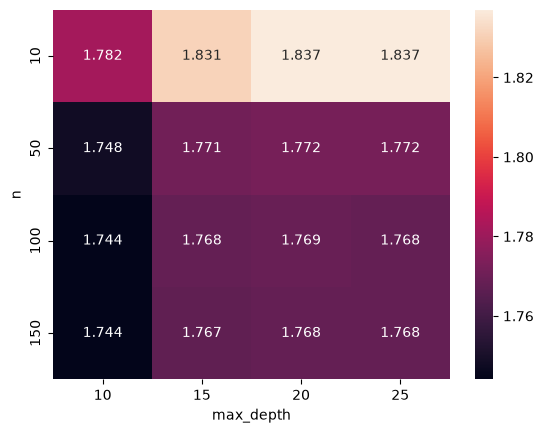

In [29]:
columns = ['max_depth', 'n', 'rmse']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores_pivot = df_scores.pivot(index='n', columns='max_depth', values='rmse')
df_scores_pivot.round(3)
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

In [34]:
"""
We can extract feature importance information from tree-based models.

At each step of the decision tree learning algorithm, it finds the best split. When doing it, we can calculate "gain" - the reduction in impurity before and after the split. This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the feature_importances_ field.

For this homework question, we'll find the most important feature:

    Train the model with these parameters:
        n_estimators=10,
        max_depth=20,
        random_state=1,
        n_jobs=-1 (optional)
    Get the feature importance information from this model

What's the most important feature (among these 4)?

    vehicle_weight
    horsepower
    acceleration
    engine_displacement
"""
rf = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_l

In [41]:
feature_importances = rf.feature_importances_
feature_names=list(dv.get_feature_names_out())
list(zip(feature_names, feature_importances))

[('acceleration', np.float64(0.054997632153652054)),
 ('drivetrain=All-wheel drive', np.float64(0.007950634892065116)),
 ('drivetrain=Front-wheel drive', np.float64(0.020062226629861492)),
 ('drivetrain=Rear-wheel drive', np.float64(0.005638475273929295)),
 ('engine_displacement', np.float64(0.06128144481858751)),
 ('fuel_type=Diesel', np.float64(0.016570533096713348)),
 ('fuel_type=Gasoline', np.float64(0.16071245288752403)),
 ('fuel_type=Hybrid', np.float64(0.016271934329480736)),
 ('horsepower', np.float64(0.07827124720421207)),
 ('model_year', np.float64(0.2961071534403154)),
 ('num_cylinders', np.float64(0.0073182361352048)),
 ('num_doors', np.float64(0.0194014677039506)),
 ('origin=Asia', np.float64(0.006514947101173604)),
 ('origin=Europe', np.float64(0.0034364358107329975)),
 ('origin=USA', np.float64(0.042151742775477855)),
 ('vehicle_weight', np.float64(0.20331343574711905))]

In [63]:
"""
Now let's train an XGBoost model! For this question, we'll tune the eta parameter:

    Install XGBoost
    Create DMatrix for train and validation
    Create a watchlist
    Train a model with these parameters for 100 rounds:

xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

Now change eta from 0.3 to 0.1.

Which eta leads to the best RMSE score on the validation dataset?

    0.3
    0.1
    Both give equal value
"""
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [64]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_rmse', 'val_rmse']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [65]:
%%capture output

xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                  verbose_eval=5,
                  evals=watchlist)

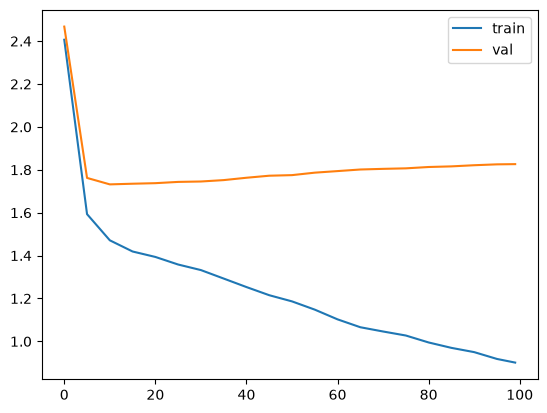

In [66]:
df_score = parse_xgb_output(output)

plt.plot(df_score.num_iter, df_score.train_rmse, label='train')
plt.plot(df_score.num_iter, df_score.val_rmse, label='val')
plt.legend()

In [67]:
print(output.stdout.strip())

[0]	train-rmse:2.40653	val-rmse:2.46782
[5]	train-rmse:1.59328	val-rmse:1.76216
[10]	train-rmse:1.47125	val-rmse:1.73205
[15]	train-rmse:1.41908	val-rmse:1.73512
[20]	train-rmse:1.39368	val-rmse:1.73766
[25]	train-rmse:1.35837	val-rmse:1.74359
[30]	train-rmse:1.33243	val-rmse:1.74548
[35]	train-rmse:1.29290	val-rmse:1.75198
[40]	train-rmse:1.25326	val-rmse:1.76296
[45]	train-rmse:1.21527	val-rmse:1.77244
[50]	train-rmse:1.18645	val-rmse:1.77517
[55]	train-rmse:1.14797	val-rmse:1.78668
[60]	train-rmse:1.10265	val-rmse:1.79401
[65]	train-rmse:1.06590	val-rmse:1.80143
[70]	train-rmse:1.04604	val-rmse:1.80444
[75]	train-rmse:1.02727	val-rmse:1.80682
[80]	train-rmse:0.99487	val-rmse:1.81308
[85]	train-rmse:0.96970	val-rmse:1.81600
[90]	train-rmse:0.94986	val-rmse:1.82135
[95]	train-rmse:0.91805	val-rmse:1.82544
[99]	train-rmse:0.90106	val-rmse:1.82646


In [68]:
%%capture output

xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model = xgb.train(xgb_params, dtrain, num_boost_round=100,
                  verbose_eval=5,
                  evals=watchlist)

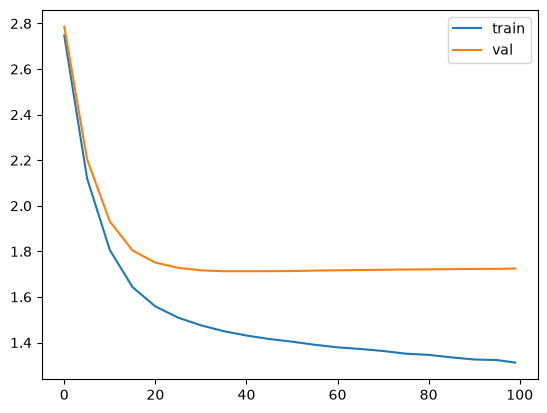

In [69]:
df_score = parse_xgb_output(output)

plt.plot(df_score.num_iter, df_score.train_rmse, label='train')
plt.plot(df_score.num_iter, df_score.val_rmse, label='val')
plt.legend()

In [70]:
print(output.stdout.strip())

[0]	train-rmse:2.74739	val-rmse:2.78635
[5]	train-rmse:2.12109	val-rmse:2.20428
[10]	train-rmse:1.80592	val-rmse:1.93152
[15]	train-rmse:1.64286	val-rmse:1.80346
[20]	train-rmse:1.55847	val-rmse:1.75076
[25]	train-rmse:1.50918	val-rmse:1.72751
[30]	train-rmse:1.47544	val-rmse:1.71667
[35]	train-rmse:1.44978	val-rmse:1.71287
[40]	train-rmse:1.43074	val-rmse:1.71289
[45]	train-rmse:1.41543	val-rmse:1.71310
[50]	train-rmse:1.40368	val-rmse:1.71358
[55]	train-rmse:1.39009	val-rmse:1.71570
[60]	train-rmse:1.37884	val-rmse:1.71688
[65]	train-rmse:1.37172	val-rmse:1.71812
[70]	train-rmse:1.36283	val-rmse:1.71919
[75]	train-rmse:1.35099	val-rmse:1.72057
[80]	train-rmse:1.34578	val-rmse:1.72100
[85]	train-rmse:1.33480	val-rmse:1.72192
[90]	train-rmse:1.32546	val-rmse:1.72303
[95]	train-rmse:1.32292	val-rmse:1.72324
[99]	train-rmse:1.31192	val-rmse:1.72481
